# 05i — Model I Training: Uncertainty-Aware / Quantile Models

Predicts the **distribution** of `lap_time_ratio` via quantile regression,
mixture density networks, or deep ensembles.

8 GPU candidates: 2 tree-quantile + 3 DL-quantile + 2 MDN + 1 ensemble.
Quantile Monte Carlo: sample from predicted distribution for principled MC.

CV: ExpandingWindowSplit (2019→2020, ..., 2019-23→2024 test).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: /opt/f1-training


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import ExpandingWindowSplit, LeaveOneSeasonOut
from f1_predictor.data.storage import (
    load_from_gcs_or_local,
    load_training_parquet,
    save_training_parquet,
    save_model_pickle as gcs_save_model_pickle,
    save_notebook,
    sync_training_from_gcs,
)
from f1_predictor.models.gpu import (
    detect_gpu_backend, get_lightgbm_device, get_torch_device, get_xgboost_device,
)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection (supports NVIDIA CUDA and AMD ROCm)
GPU_BACKEND, GPU_NAME = detect_gpu_backend()
TORCH_DEVICE = get_torch_device()
print(f"GPU backend: {GPU_BACKEND} ({GPU_NAME})")
print(f"PyTorch device: {TORCH_DEVICE}")

# Deep learning models (PyTorch — works on both CUDA and ROCm via HIP)
DL_AVAILABLE = False
try:
    from f1_predictor.models.architectures import GRU2Layer, FTTransformerWrapper, MLP3Layer
    DL_AVAILABLE = TORCH_DEVICE != "cpu"
    print(f"DL models available: {DL_AVAILABLE}")
except (ImportError, NameError):
    print("DL models not available (torch/rtdl not installed)")

GPU backend: cuda (Tesla V100-SXM2-16GB)
PyTorch device: cuda
DL models available: True


In [3]:
def save_predictions(model, X, y, id_df, model_type, model_name, split_name):
    """Save prediction parquet locally and to GCS."""
    preds = model.predict(X)
    out = id_df.copy()
    out["y_true"] = y.values
    out["y_pred"] = preds
    fname = f"model_{model_type}_{model_name}_{split_name}.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")
    return preds


def save_model_pkl(model, model_type, model_name):
    """Save model pickle locally and to GCS."""
    fname = f"Model_{model_type}_{model_name}.pkl"
    uri = gcs_save_model_pickle(model, fname, MODEL_DIR)
    print(f"  Saved {fname} -> {uri}")

In [4]:
import sys
from datetime import datetime, timezone

class ProgressLogger:
    def __init__(self, model_key, log_dir="/var/log"):
        self.model_key = model_key
        self.log_path = f"{log_dir}/f1-model-{model_key.lower()}-progress.log"
        try:
            self._f = open(self.log_path, "a", buffering=1)
        except OSError:
            self._f = None

    def log(self, msg):
        ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
        line = f"[Model {self.model_key}] [{ts}] {msg}"
        print(line, flush=True)
        if self._f:
            self._f.write(line + "\n")
            self._f.flush()

    def round_header(self, round_num, desc):
        self.log(f"========== ROUND {round_num}: {desc} ==========")

    def screening(self, name, idx, total, rmse=None, error=None):
        if error:
            self.log(f"Screening {idx}/{total} {name} -- FAILED: {error}")
        else:
            self.log(f"Screening {idx}/{total} {name} -- RMSE: {rmse:.6f}")

    def optuna_trial(self, name, trial_num, total, rmse, best_rmse):
        self.log(f"{name} trial {trial_num}/{total} -- RMSE: {rmse:.6f} (best: {best_rmse:.6f})")

    def model_complete(self, name, round_num, rmse):
        self.log(f"{name} Round {round_num} COMPLETE -- best RMSE: {rmse:.6f}")

    def close(self):
        if self._f:
            self._f.close()

progress = ProgressLogger("I")

In [5]:
import json as _json_slack
import os as _os_slack
from urllib.request import Request as _SlackReq, urlopen as _slack_urlopen

class SlackNotifier:
    def __init__(self, model_key):
        self.model_key = model_key
        self.webhook_url = _os_slack.environ.get("SLACK_WEBHOOK_URL", "")
        self.enabled = bool(self.webhook_url)

    def send(self, text):
        if not self.enabled:
            return
        try:
            data = _json_slack.dumps({"text": text}).encode()
            req = _SlackReq(self.webhook_url, data=data,
                            headers={"Content-Type": "application/json"})
            _slack_urlopen(req, timeout=10)
        except Exception:
            pass

    def round_start(self, round_num, desc, n_models):
        self.send(f":racing_car: *Model {self.model_key} -- Round {round_num}*\n{desc} ({n_models} models)")

    def round_complete(self, round_num, summary):
        self.send(f":checkered_flag: *Model {self.model_key} -- Round {round_num} complete*\n{summary}")

    def model_start(self):
        self.send(f":rocket: *Model {self.model_key} training STARTED*")

    def model_complete(self, best_model, best_rmse):
        self.send(f":tada: *Model {self.model_key} training COMPLETE*\nBest: {best_model} (RMSE: {best_rmse:.6f})")

    def architecture_done(self, name, round_num, rmse):
        self.send(f":gear: Model {self.model_key} R{round_num} -- {name} done (RMSE: {rmse:.6f})")

    def error(self, context, error_msg):
        self.send(f":rotating_light: *Model {self.model_key} ERROR* -- {context}: {error_msg}")

slack = SlackNotifier("I")

In [6]:
import json as _json_ckpt
import subprocess as _sp_ckpt
from datetime import datetime as _dt_ckpt, timezone as _tz_ckpt
from pathlib import Path as _Path_ckpt

class CheckpointManager:
    def __init__(self, model_key, local_base="/opt/f1-training/checkpoints",
                 bucket="f1-predictor-artifacts-jowin",
                 gcs_prefix="staging/training-run/checkpoints"):
        self.model_key = model_key
        self.local_dir = _Path_ckpt(local_base) / f"model_{model_key}"
        self.local_dir.mkdir(parents=True, exist_ok=True)
        self.gcs_prefix = f"gs://{bucket}/{gcs_prefix}/model_{model_key}"
        self._sync_from_gcs()

    def _sync_from_gcs(self):
        try:
            _sp_ckpt.run(
                ["gsutil", "-m", "-q", "cp", "-r",
                 f"{self.gcs_prefix}/*", str(self.local_dir) + "/"],
                capture_output=True, timeout=60)
        except Exception:
            pass

    def _upload(self, local_path):
        name = _Path_ckpt(local_path).name
        try:
            _sp_ckpt.run(
                ["gsutil", "-q", "cp", str(local_path),
                 f"{self.gcs_prefix}/{name}"],
                capture_output=True, timeout=30)
        except Exception:
            pass

    def save_checkpoint(self, round_num, arch_name, rmse, best_params, **extra):
        data = {
            "model_key": self.model_key,
            "round": round_num,
            "architecture": arch_name,
            "rmse": rmse,
            "best_params": best_params,
            "timestamp": _dt_ckpt.now(_tz_ckpt.utc).isoformat(),
            **extra,
        }
        path = self.local_dir / f"round_{round_num}_{arch_name}.json"
        path.write_text(_json_ckpt.dumps(data, indent=2, default=str))
        self._upload(path)

    def load_checkpoint(self, round_num, arch_name):
        path = self.local_dir / f"round_{round_num}_{arch_name}.json"
        if path.exists():
            return _json_ckpt.loads(path.read_text())
        return None

    def get_completed(self, round_num):
        result = {}
        for p in sorted(self.local_dir.glob(f"round_{round_num}_*.json")):
            if p.stem.endswith("_summary"):
                continue
            data = _json_ckpt.loads(p.read_text())
            result[data["architecture"]] = data
        return result

    def save_round_summary(self, round_num, results_list, top_names):
        data = {"round": round_num, "results": results_list, "top_names": top_names,
                "timestamp": _dt_ckpt.now(_tz_ckpt.utc).isoformat()}
        path = self.local_dir / f"round_{round_num}_summary.json"
        path.write_text(_json_ckpt.dumps(data, indent=2, default=str))
        self._upload(path)

    def load_round_summary(self, round_num):
        path = self.local_dir / f"round_{round_num}_summary.json"
        if path.exists():
            return _json_ckpt.loads(path.read_text())
        return None

ckpt = CheckpointManager("I")

In [7]:
slack.model_start()
progress.log('Starting Model I training')

[Model I] [2026-04-29 09:43:52 UTC] Starting Model I training


## 1. Build Training Data

In [8]:
from f1_predictor.features.simulation_features import (
    build_simulation_training_data,
    SIMULATION_FEATURE_COLS,
)

laps = load_from_gcs_or_local(
    "data/raw/laps/all_laps.parquet",
    Path("data/raw/laps/all_laps.parquet"),
)
races = load_from_gcs_or_local(
    "data/raw/race/all_races.parquet",
    Path("data/raw/race/all_races.parquet"),
)

df = build_simulation_training_data(laps, races)
print(f"Shape: {df.shape}")
print(f"Target stats:\n{df['lap_time_ratio'].describe()}")

Shape: (78606, 31)
Target stats:
count    78606.000000
mean         1.102322
std          0.085287
min          0.950075
25%          1.064921
50%          1.080491
75%          1.100085
max          1.599968
Name: lap_time_ratio, dtype: float64


In [9]:
FEATURE_COLS = SIMULATION_FEATURE_COLS
TARGET = "lap_time_ratio"
ID_COLS = ["season", "round", "event_name", "driver_abbrev", "team"]

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

X = df[FEATURE_COLS]
y = df[TARGET]
groups = df["season"].values
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features (25): ['grid_position', 'best_quali_sec', 'circuit_street', 'circuit_hybrid', 'circuit_permanent', 'lap_number', 'race_progress_pct', 'compound_HARD', 'compound_INTERMEDIATE', 'compound_MEDIUM', 'compound_SOFT', 'compound_WET', 'tire_life', 'stint', 'is_pit_in_lap', 'is_pit_out_lap', 'pit_stop_count', 'laps_since_last_pit', 'lap_time_rolling_3', 'lap_time_rolling_5', 'degradation_rate', 'gap_to_leader', 'position', 'position_change_from_lap1', 'is_caution']
X shape: (78606, 25), y shape: (78606,)


## 2. CV Splitter

In [10]:
splitter = ExpandingWindowSplit(
    fold_definitions=[
        ([2019], 2020),
        ([2019, 2020], 2021),
        ([2019, 2020, 2021], 2022),
        ([2019, 2020, 2021, 2022], 2023),
    ],
    test_season=2024,
)
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    tr_seasons = sorted(set(groups[tr]))
    va_seasons = sorted(set(groups[va]))
    print(f"  Fold {i}: train={tr_seasons}, val={va_seasons}, "
          f"train={len(tr):,}, val={len(va):,}")

CV folds: 4
  Fold 0: train=[np.int64(2019)], val=[np.int64(2020)], train=22,496, val=15,483
  Fold 1: train=[np.int64(2019), np.int64(2020)], val=[np.int64(2021)], train=37,979, val=22,112
  Fold 2: train=[np.int64(2019), np.int64(2020), np.int64(2021)], val=[np.int64(2022)], train=60,091, val=10,038
  Fold 3: train=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], val=[np.int64(2023)], train=70,129, val=3,690


## 3. Model Candidates and Helpers

8 uncertainty-aware candidates, all Optuna-tunable.

In [11]:
from f1_predictor.models.quantile_architectures import (
    LightGBM_Quantile, XGBoost_Quantile,
    MLP_MultiQuantile, GRU_MultiQuantile, FTTransformer_Quantile,
    MDN_MLP, MDN_GRU, DeepEnsemble,
)

DL_SKIP_OPTUNA = set()  # all models tunable
NAN_TOLERANT = {"LightGBM_Quantile", "XGBoost_Quantile"}

MODEL_CLASSES_I = {
    "LightGBM_Quantile": LightGBM_Quantile,
    "XGBoost_Quantile": XGBoost_Quantile,
}
if DL_AVAILABLE:
    MODEL_CLASSES_I.update({
        "MLP_MultiQuantile": MLP_MultiQuantile,
        "GRU_MultiQuantile": GRU_MultiQuantile,
        "FTTransformer_Quantile": FTTransformer_Quantile,
        "MDN_MLP": MDN_MLP,
        "MDN_GRU": MDN_GRU,
        "DeepEnsemble": DeepEnsemble,
    })


def get_candidates_i():
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)
    candidates = {
        "LightGBM_Quantile": LightGBM_Quantile(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Quantile": XGBoost_Quantile(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
    }
    if DL_AVAILABLE:
        n_feat = len(FEATURE_COLS)
        candidates["MLP_MultiQuantile"] = MLP_MultiQuantile(input_dim=n_feat)
        candidates["GRU_MultiQuantile"] = GRU_MultiQuantile(input_dim=n_feat)
        candidates["FTTransformer_Quantile"] = FTTransformer_Quantile(input_dim=n_feat)
        candidates["MDN_MLP"] = MDN_MLP(input_dim=n_feat)
        candidates["MDN_GRU"] = MDN_GRU(input_dim=n_feat)
        candidates["DeepEnsemble"] = DeepEnsemble(input_dim=n_feat)
    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def _tree_quantile_space(trial, tree_type):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )
    if tree_type == "xgb":
        xgb_device = get_xgboost_device(GPU_BACKEND)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    else:
        lgb_device = get_lightgbm_device(GPU_BACKEND)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    return params


def _dl_quantile_space(trial, model_cls):
    params = {"input_dim": len(FEATURE_COLS)}
    if model_cls in (MLP_MultiQuantile, MDN_MLP, DeepEnsemble):
        params["hidden1"] = trial.suggest_categorical("hidden1", [64, 128, 256])
        params["hidden2"] = trial.suggest_categorical("hidden2", [32, 64, 128])
    if model_cls in (GRU_MultiQuantile, MDN_GRU):
        params["hidden_dim"] = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
        params["num_layers"] = trial.suggest_int("num_layers", 1, 3)
    if model_cls == FTTransformer_Quantile:
        params["d_token"] = trial.suggest_categorical("d_token", [32, 64, 128])
        params["n_blocks"] = trial.suggest_int("n_blocks", 1, 4)
    params["dropout"] = trial.suggest_float("dropout", 0.05, 0.5)
    params["lr"] = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    params["weight_decay"] = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    if model_cls in (MDN_MLP, MDN_GRU):
        params["n_components"] = trial.suggest_int("n_components", 2, 5)
    if model_cls == DeepEnsemble:
        params["n_members"] = trial.suggest_int("n_members", 3, 7)
    return params


def get_optuna_param_space_i(name, trial):
    if name == "LightGBM_Quantile":
        return _tree_quantile_space(trial, "lgb")
    elif name == "XGBoost_Quantile":
        return _tree_quantile_space(trial, "xgb")
    else:
        return _dl_quantile_space(trial, MODEL_CLASSES_I[name])


def reconstruct_params_i(name, best_params):
    params = dict(best_params)
    if name == "XGBoost_Quantile":
        xgb_device = get_xgboost_device(GPU_BACKEND)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "LightGBM_Quantile":
        lgb_device = get_lightgbm_device(GPU_BACKEND)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    else:
        params.setdefault("input_dim", len(FEATURE_COLS))
    return params

In [12]:
def cv_evaluate_i(model, X, y, splitter, groups):
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmses, maes = [], []
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        m = sklearn.base.clone(model)
        X_tr = X.iloc[tr_idx] if hasattr(X, "iloc") else X[tr_idx]
        y_tr = y.iloc[tr_idx] if hasattr(y, "iloc") else y[tr_idx]
        X_va = X.iloc[va_idx] if hasattr(X, "iloc") else X[va_idx]
        y_va = y.iloc[va_idx] if hasattr(y, "iloc") else y[va_idx]
        name_str = type(model).__name__
        if name_str in str(NAN_TOLERANT) or any(n in str(type(model)) for n in ["XGB", "LGB"]):
            m.fit(X_tr, y_tr)
        else:
            X_tr_clean = X_tr.fillna(0) if hasattr(X_tr, "fillna") else np.nan_to_num(X_tr)
            X_va_clean = X_va.fillna(0) if hasattr(X_va, "fillna") else np.nan_to_num(X_va)
            m.fit(X_tr_clean, y_tr)
            X_va = X_va_clean
        # Use median prediction (q50) for RMSE
        preds = m.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        maes.append(mean_absolute_error(y_va, preds))
    return {"mean_rmse": np.mean(rmses), "std_rmse": np.std(rmses), "mean_mae": np.mean(maes)}


def screen_models_i(candidates, X, y, splitter, groups):
    rows = []
    completed = ckpt.get_completed(1)
    total = len(candidates)
    for idx, (name, model) in enumerate(candidates.items(), 1):
        if name in completed:
            cp = completed[name]
            rows.append({"model": name, "mean_rmse": cp["rmse"],
                         "std_rmse": cp.get("std_rmse", 0), "mean_mae": cp.get("mean_mae", 0)})
            progress.log(f"Screening {idx}/{total} {name} -- RESUMED (RMSE: {cp['rmse']:.6f})")
            continue
        try:
            result = cv_evaluate_i(model, X, y, splitter, groups)
            rows.append({"model": name, **result})
            progress.screening(name, idx, total, rmse=result["mean_rmse"])
            ckpt.save_checkpoint(1, name, result["mean_rmse"], {},
                                 std_rmse=result["std_rmse"], mean_mae=result["mean_mae"])
        except Exception as e:
            progress.screening(name, idx, total, error=str(e))
            slack.error(f"R1 screening {name}", str(e))
    if not rows:
        raise RuntimeError("All candidates failed — check data for NaN or shape issues")
    return pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)


def run_optuna_round_i(name, X, y, splitter, groups, n_trials):
    def objective(trial):
        params = get_optuna_param_space_i(name, trial)
        model_cls = MODEL_CLASSES_I[name]
        model = model_cls(**params)
        result = cv_evaluate_i(model, X, y, splitter, groups)
        return result["mean_rmse"]
    def _trial_cb(study, trial):
        if trial.value is not None:
            progress.optuna_trial(name, trial.number + 1, n_trials, trial.value, study.best_value)
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(
        objective, n_trials=n_trials,
        catch=(Exception,), show_progress_bar=False,
        callbacks=[_trial_cb],
    )
    return study.best_params, study.best_value

## 4. Round 1 — Screen Models

In [13]:
progress.round_header(1, "Screen all candidates")
slack.round_start(1, "Screening all candidates", len(get_candidates_i()))
candidates = get_candidates_i()
r1_results = screen_models_i(candidates, X, y, splitter, groups)
ckpt.save_round_summary(1, r1_results.to_dict("records"), r1_results["model"].head(min(7, len(r1_results))).tolist())
slack.round_complete(1, f"Best: {r1_results.iloc[0]['model']} (RMSE: {r1_results.iloc[0]['mean_rmse']:.6f})")
r1_results[["model", "mean_rmse", "std_rmse", "mean_mae"]]

[Model I] [2026-04-29 09:44:08 UTC] ========== ROUND 1: Screen all candidates ==========


Candidates (8): ['LightGBM_Quantile', 'XGBoost_Quantile', 'MLP_MultiQuantile', 'GRU_MultiQuantile', 'FTTransformer_Quantile', 'MDN_MLP', 'MDN_GRU', 'DeepEnsemble']


Candidates (8): ['LightGBM_Quantile', 'XGBoost_Quantile', 'MLP_MultiQuantile', 'GRU_MultiQuantile', 'FTTransformer_Quantile', 'MDN_MLP', 'MDN_GRU', 'DeepEnsemble']


[Model I] [2026-04-29 12:05:47 UTC] Screening 1/8 LightGBM_Quantile -- RMSE: 0.059974


[Model I] [2026-04-29 12:06:13 UTC] Screening 2/8 XGBoost_Quantile -- RMSE: 0.064356


...

[Model I] [2026-04-29 12:16:06 UTC] Screening 5/8 FTTransformer_Quantile -- RMSE: 0.060191


[Model I] [2026-04-29 12:20:13 UTC] Screening 6/8 MDN_MLP -- RMSE: 0.064273


[Model I] [2026-04-29 12:23:27 UTC] Screening 7/8 MDN_GRU -- RMSE: 0.065186


[Model I] [2026-04-29 12:36:36 UTC] Screening 8/8 DeepEnsemble -- RMSE: 0.066854


,model,mean_rmse,std_rmse,mean_mae
0,LightGBM_Quantile,0.059974,0.008295,0.028670
1,FTTransformer_Quantile,0.060191,0.007182,0.029540
2,GRU_MultiQuantile,0.062144,0.008156,0.029325
3,MDN_MLP,0.064273,0.006966,0.031928
4,XGBoost_Quantile,0.064356,0.011917,0.030939
5,MDN_GRU,0.065186,0.007540,0.033190
6,DeepEnsemble,0.066854,0.009108,0.037715
7,MLP_MultiQuantile,0.066883,0.009911,0.032967


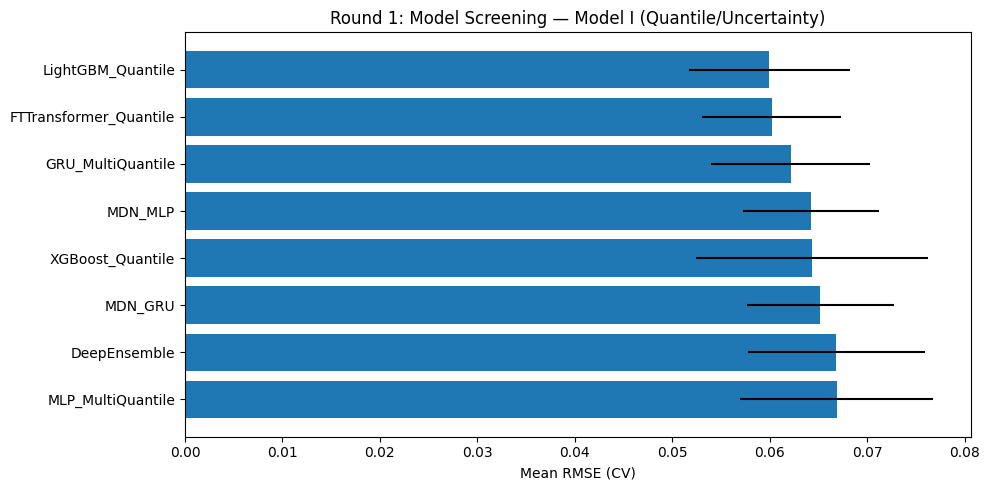

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r1_results["model"], r1_results["mean_rmse"], xerr=r1_results["std_rmse"])
ax.set_xlabel("Mean RMSE (CV)")
ax.set_title("Round 1: Model Screening — Model I (Quantile/Uncertainty)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
r1_summary = ckpt.load_round_summary(1)
if r1_summary:
    top7_names = r1_summary["top_names"]
else:
    top7_names = r1_results["model"].head(min(7, len(r1_results))).tolist()
print(f"Advancing to Round 2: {top7_names}")
eliminated = [n for n in r1_results["model"].tolist() if n not in top7_names]
if eliminated:
    print(f"Eliminated: {eliminated}")

Advancing to Round 2: ['LightGBM_Quantile', 'FTTransformer_Quantile', 'GRU_MultiQuantile', 'MDN_MLP', 'XGBoost_Quantile', 'MDN_GRU', 'DeepEnsemble']
Eliminated: ['MLP_MultiQuantile']


## 5. Round 2 — Optuna (top 7, 10 trials each)

In [16]:
progress.round_header(2, "Optuna HP tuning (top 7, 10 trials each)")
slack.round_start(2, "Optuna HP tuning", len(top7_names))
r2_results = []
completed_r2 = ckpt.get_completed(2)
for idx, name in enumerate(top7_names, 1):
    if name in completed_r2:
        cp = completed_r2[name]
        r2_results.append({"model": name, "best_rmse": cp["rmse"], "best_params": cp["best_params"]})
        progress.log(f"{name} -- RESUMED from checkpoint (RMSE: {cp['rmse']:.6f})")
        continue
    progress.log(f"Tuning {name} ({idx}/{len(top7_names)})...")
    try:
        best_params, best_rmse = run_optuna_round_i(
            name, X, y, splitter, groups, n_trials=10)
        r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
        ckpt.save_checkpoint(2, name, best_rmse, best_params)
        progress.model_complete(name, 2, best_rmse)
        slack.architecture_done(name, 2, best_rmse)
    except Exception as e:
        progress.log(f"{name} FAILED in Round 2: {e}")
        slack.error(f"R2 {name}", str(e))

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
ckpt.save_round_summary(2, r2_results, r2_df["model"].head(5).tolist())
slack.round_complete(2, f"Top 5: {r2_df['model'].head(5).tolist()}")
r2_df[["model", "best_rmse"]]

[Model I] [2026-04-29 12:36:42 UTC] ========== ROUND 2: Optuna HP tuning (top 7, 10 trials each) ==========


[Model I] [2026-04-29 12:36:42 UTC] Tuning LightGBM_Quantile (1/7)...


[Model I] [2026-04-29 13:34:53 UTC] LightGBM_Quantile trial 1/10 -- RMSE: 0.055385 (best: 0.055385)


[Model I] [2026-04-29 13:36:43 UTC] LightGBM_Quantile trial 2/10 -- RMSE: 0.059432 (best: 0.055385)


[Model I] [2026-04-29 13:37:03 UTC] LightGBM_Quantile trial 3/10 -- RMSE: 0.062588 (best: 0.055385)


...

[Model I] [2026-04-29 16:55:25 UTC] DeepEnsemble trial 8/10 -- RMSE: 0.158758 (best: 0.061272)


[Model I] [2026-04-29 17:06:32 UTC] DeepEnsemble trial 9/10 -- RMSE: 0.076919 (best: 0.061272)


[Model I] [2026-04-29 17:13:24 UTC] DeepEnsemble trial 10/10 -- RMSE: 0.070114 (best: 0.061272)


[Model I] [2026-04-29 17:13:26 UTC] DeepEnsemble Round 2 COMPLETE -- best RMSE: 0.061272


,model,best_rmse
0,LightGBM_Quantile,0.055385
1,XGBoost_Quantile,0.057676
2,GRU_MultiQuantile,0.058866
3,FTTransformer_Quantile,0.059307
4,MDN_GRU,0.060277
5,DeepEnsemble,0.061272
6,MDN_MLP,0.064261


In [17]:
r2_summary = ckpt.load_round_summary(2)
if r2_summary:
    top5_names = r2_summary["top_names"]
else:
    top5_names = r2_df["model"].head(5).tolist()
r2_best_params = {row["model"]: row["best_params"] for _, row in r2_df.iterrows() if "best_params" in row}
print(f"Advancing to Round 3: {top5_names}")

Advancing to Round 3: ['LightGBM_Quantile', 'XGBoost_Quantile', 'GRU_MultiQuantile', 'FTTransformer_Quantile', 'MDN_GRU']


## 6. Round 3 — Final Tuning (top 5, 15 trials each)

In [18]:
progress.round_header(3, "Final tuning (top 5, 15 trials each)")
slack.round_start(3, "Final Optuna tuning", len(top5_names))
r3_results = []
completed_r3 = ckpt.get_completed(3)
for idx, name in enumerate(top5_names, 1):
    if name in completed_r3:
        cp = completed_r3[name]
        r3_results.append({"model": name, "best_rmse": cp["rmse"], "best_params": cp["best_params"]})
        progress.log(f"{name} -- RESUMED from checkpoint (RMSE: {cp['rmse']:.6f})")
        continue
    progress.log(f"Fine-tuning {name} ({idx}/{len(top5_names)})...")
    try:
        best_params, best_rmse = run_optuna_round_i(
            name, X, y, splitter, groups, n_trials=15)
        r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
        ckpt.save_checkpoint(3, name, best_rmse, best_params)
        progress.model_complete(name, 3, best_rmse)
        slack.architecture_done(name, 3, best_rmse)
    except Exception as e:
        progress.log(f"{name} FAILED in Round 3: {e}")
        slack.error(f"R3 {name}", str(e))

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows() if "best_params" in row}
ckpt.save_round_summary(3, r3_results, r3_df["model"].head(5).tolist())
slack.round_complete(3, f"Best: {r3_df.iloc[0]['model']} (RMSE: {r3_df.iloc[0]['best_rmse']:.6f})")
r3_df[["model", "best_rmse"]]

[Model I] [2026-04-29 17:13:28 UTC] ========== ROUND 3: Final tuning (top 5, 15 trials each) ==========


[Model I] [2026-04-29 17:13:28 UTC] Fine-tuning LightGBM_Quantile (1/5)...


[Model I] [2026-04-29 17:14:35 UTC] LightGBM_Quantile trial 1/15 -- RMSE: 0.055385 (best: 0.055385)


[Model I] [2026-04-29 17:16:25 UTC] LightGBM_Quantile trial 2/15 -- RMSE: 0.059432 (best: 0.055385)


[Model I] [2026-04-29 17:16:46 UTC] LightGBM_Quantile trial 3/15 -- RMSE: 0.062588 (best: 0.055385)


...

[Model I] [2026-04-29 19:37:54 UTC] MDN_GRU trial 13/15 -- RMSE: 0.067266 (best: 0.063690)


[Model I] [2026-04-29 19:39:59 UTC] MDN_GRU trial 14/15 -- RMSE: 0.070316 (best: 0.063690)


[Model I] [2026-04-29 19:42:31 UTC] MDN_GRU trial 15/15 -- RMSE: 0.064764 (best: 0.063690)


[Model I] [2026-04-29 19:42:33 UTC] MDN_GRU Round 3 COMPLETE -- best RMSE: 0.063690


,model,best_rmse
0,LightGBM_Quantile,0.055385
1,XGBoost_Quantile,0.057495
2,FTTransformer_Quantile,0.059425
3,GRU_MultiQuantile,0.059502
4,MDN_GRU,0.063690


## 7. Test Set Evaluation (Per-Lap)

In [19]:
train_idx, test_idx = splitter.get_test_split(groups)
X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
id_train, id_test = df[ID_COLS].iloc[train_idx], df[ID_COLS].iloc[test_idx]

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Test season(s): {sorted(df['season'].iloc[test_idx].unique())}")

Train: (73819, 25), Test: (4787, 25)
Test season(s): [np.int64(2024)]


In [20]:
final_results = []
for name in top5_names:
    params = reconstruct_params_i(name, r3_best_params[name])
    model_cls = MODEL_CLASSES_I[name]
    model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    train_preds = model.predict(X_train_full)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))

    test_preds = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name,
        "train_rmse": train_rmse, "val_rmse": val_rmse,
        "test_rmse": test_rmse, "overfit_gap": test_rmse - val_rmse,
    })
    print(f"{name}: train_rmse={train_rmse:.4f}, val_rmse={val_rmse:.4f}, "
          f"test_rmse={test_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

LightGBM_Quantile: train_rmse=0.0390, val_rmse=0.0554, test_rmse=0.0178


XGBoost_Quantile: train_rmse=0.0461, val_rmse=0.0575, test_rmse=0.0209


GRU_MultiQuantile: train_rmse=0.0445, val_rmse=0.0595, test_rmse=0.0215


FTTransformer_Quantile: train_rmse=0.0557, val_rmse=0.0594, test_rmse=0.0322


MDN_GRU: train_rmse=0.0735, val_rmse=0.0637, test_rmse=0.0375


,model,train_rmse,val_rmse,test_rmse,overfit_gap
0,LightGBM_Quantile,0.038986,0.055385,0.017808,-0.037577
1,XGBoost_Quantile,0.046125,0.057495,0.020864,-0.036632
2,GRU_MultiQuantile,0.044451,0.059502,0.021456,-0.038046
3,FTTransformer_Quantile,0.055683,0.059425,0.032195,-0.027230
4,MDN_GRU,0.073497,0.063690,0.037474,-0.026217


## 8. Quantile Monte Carlo Simulation (2024 Test Races)

In [21]:
from f1_predictor.simulation.quantile_simulator import QuantileRaceSimulator
from f1_predictor.simulation.defaults import build_circuit_defaults
from f1_predictor.simulation.evaluation import evaluate_simulation, evaluate_monte_carlo_calibration
from f1_predictor.features.race_features import LOCATION_ALIASES

circuit_defaults = build_circuit_defaults(laps)

# Retrain best quantile model on full training set
best_model_name = final_df.iloc[0]["model"]
best_params = reconstruct_params_i(best_model_name, r3_best_params[best_model_name])
best_model = MODEL_CLASSES_I[best_model_name](**best_params)
best_model.fit(X_train_full, y_train_full)

qmc_sim = QuantileRaceSimulator(
    best_model, circuit_defaults, n_simulations=200, seed=42)
print(f"Quantile MC simulator: {best_model_name}, N=200 runs")

Quantile MC simulator: LightGBM_Quantile, N=200 runs


In [22]:
test_races = races[races["season"] == 2024].copy()
test_race_list = test_races.groupby(
    ["season", "round", "event_name"]).first().reset_index()

# Single-run (q50 only)
from f1_predictor.simulation.engine import RaceSimulator
single_sim = RaceSimulator(best_model, circuit_defaults)

sim_results = []
mc_results_all = []

for _, race_row in test_race_list.iterrows():
    event = race_row["event_name"]
    event_norm = LOCATION_ALIASES.get(event, event)

    if event_norm not in circuit_defaults:
        print(f"  Skipping {event} (no circuit data)")
        continue

    race_drivers = test_races[
        (test_races["season"] == race_row["season"])
        & (test_races["round"] == race_row["round"])
    ].copy()

    drivers_input = []
    actual_positions = {}
    for _, drv in race_drivers.iterrows():
        q1 = drv.get("q1_time_sec")
        q2 = drv.get("q2_time_sec")
        q3 = drv.get("q3_time_sec")
        q_times = [t for t in [q1, q2, q3] if pd.notna(t)]
        if not q_times or pd.isna(drv.get("grid_position")):
            continue
        drivers_input.append({
            "driver": drv["driver_abbrev"],
            "grid_position": int(drv["grid_position"]),
            "q1": q1 if pd.notna(q1) else None,
            "q2": q2 if pd.notna(q2) else None,
            "q3": q3 if pd.notna(q3) else None,
            "initial_tyre": "MEDIUM",
        })
        if pd.notna(drv.get("finish_position")):
            actual_positions[drv["driver_abbrev"]] = int(drv["finish_position"])

    if len(drivers_input) < 10:
        continue

    try:
        # Single-run (median) simulation
        result = single_sim.simulate(event_norm, drivers_input)
        for fr in result.final_results:
            if fr["driver"] in actual_positions:
                sim_results.append({
                    "event": event, "driver": fr["driver"],
                    "predicted_pos": fr["position"],
                    "actual_pos": actual_positions[fr["driver"]],
                })

        # Quantile Monte Carlo
        mc_result = qmc_sim.simulate(event_norm, drivers_input)
        for r in mc_result.results:
            if r["driver"] in actual_positions:
                mc_results_all.append({
                    **r, "event": event,
                    "actual_pos": actual_positions[r["driver"]],
                    "predicted_pos": r["position"],
                })
        print(f"  {event}: simulated {len(drivers_input)} drivers")
    except Exception as e:
        print(f"  {event}: failed — {e}")

sim_df = pd.DataFrame(sim_results)
mc_df = pd.DataFrame(mc_results_all)
print(f"\nSingle-run results: {len(sim_df)} driver-race predictions")
print(f"Quantile MC results: {len(mc_df)} driver-race predictions")

  Bahrain Grand Prix: simulated 20 drivers


  Emilia Romagna Grand Prix: simulated 19 drivers


  Hungarian Grand Prix: simulated 20 drivers


  Mexico City Grand Prix: simulated 20 drivers

Single-run results: 79 driver-race predictions
Quantile MC results: 79 driver-race predictions


In [23]:
# Single-run metrics
if len(sim_df) > 0:
    single_metrics = evaluate_simulation(sim_df)
    print("=" * 60)
    print("MODEL I — SINGLE-RUN (MEDIAN) SIMULATION (2024)")
    print("=" * 60)
    for k, v in single_metrics.items():
        print(f"  {k:20s}: {v}")

# Quantile MC metrics
if len(mc_df) > 0:
    mc_sim_metrics = evaluate_simulation(mc_df)
    mc_cal_metrics = evaluate_monte_carlo_calibration(mc_df.to_dict("records"))
    print()
    print("=" * 60)
    print("MODEL I — QUANTILE MC SIMULATION (N=200, 2024)")
    print("=" * 60)
    for k, v in mc_sim_metrics.items():
        print(f"  {k:20s}: {v}")
    print()
    print("Calibration:")
    for k, v in mc_cal_metrics.items():
        print(f"  {k:20s}: {v}")

MODEL I — SINGLE-RUN (MEDIAN) SIMULATION (2024)
  position_rmse       : 6.989141668747514
  position_mae        : 5.506329113924051
  r2                  : -0.47446798220158626
  within_1            : 17.72151898734177
  within_3            : 40.50632911392405
  within_5            : 58.22784810126582
  spearman_mean       : 0.2604636591478697
  n_races             : 4

MODEL I — QUANTILE MC SIMULATION (N=200, 2024)
  position_rmse       : 6.822338587131861
  position_mae        : 5.556962025316456
  r2                  : -0.40492841942348634
  within_1            : 20.253164556962027
  within_3            : 35.44303797468354
  within_5            : 50.63291139240506
  spearman_mean       : 0.15545481267734157
  n_races             : 4

Calibration:
  coverage_80         : 54.43037974683544
  coverage_50         : 35.44303797468354
  sharpness_80        : 9.886075949367088
  sharpness_50        : 6.075949367088608


## 9. Save Artifacts

In [24]:
for name in top5_names:
    params = reconstruct_params_i(name, r3_best_params[name])
    model = MODEL_CLASSES_I[name](**params)
    model.fit(X_train_full, y_train_full)

    save_predictions(model, X_train_full, y_train_full, id_train, "I", name, "Training")
    save_predictions(model, X_test, y_test, id_test, "I", name, "Test")

    oof_preds = np.full(len(X), np.nan)
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_preds[va_idx] = fold_model.predict(X.iloc[va_idx])

    val_mask = ~np.isnan(oof_preds)
    val_out = df[ID_COLS].loc[val_mask].copy()
    val_out["y_true"] = y.loc[val_mask].values
    val_out["y_pred"] = oof_preds[val_mask]
    fname = f"model_I_{name}_Validation.parquet"
    uri = save_training_parquet(val_out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    save_model_pkl(model, "I", name)

print("\nDone! All Model I artifacts saved.")

  Saved model_I_LightGBM_Quantile_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_LightGBM_Quantile_Training.parquet
  Saved model_I_LightGBM_Quantile_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_LightGBM_Quantile_Test.parquet


  Saved model_I_LightGBM_Quantile_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_LightGBM_Quantile_Validation.parquet


  Saved Model_I_LightGBM_Quantile.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_I_LightGBM_Quantile.pkl


  Saved model_I_XGBoost_Quantile_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_XGBoost_Quantile_Training.parquet
  Saved model_I_XGBoost_Quantile_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_XGBoost_Quantile_Test.parquet


  Saved model_I_XGBoost_Quantile_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_XGBoost_Quantile_Validation.parquet


...

  Saved Model_I_GRU_MultiQuantile.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_I_GRU_MultiQuantile.pkl


  Saved model_I_FTTransformer_Quantile_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_FTTransformer_Quantile_Training.parquet
  Saved model_I_FTTransformer_Quantile_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_FTTransformer_Quantile_Test.parquet


  Saved model_I_FTTransformer_Quantile_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_FTTransformer_Quantile_Validation.parquet
  Saved Model_I_FTTransformer_Quantile.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_I_FTTransformer_Quantile.pkl


  Saved model_I_MDN_GRU_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_MDN_GRU_Training.parquet
  Saved model_I_MDN_GRU_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_MDN_GRU_Test.parquet


  Saved model_I_MDN_GRU_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_I_MDN_GRU_Validation.parquet
  Saved Model_I_MDN_GRU.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_I_MDN_GRU.pkl

Done! All Model I artifacts saved.


## Summary

In [25]:
print("=" * 60)
print("MODEL I (UNCERTAINTY / QUANTILE) TRAINING COMPLETE")
print("=" * 60)
print(f"\nPer-lap evaluation (top 5, sorted by test RMSE):")
for _, row in final_df.iterrows():
    print(f"  {row['model']:30s}  test_rmse={row['test_rmse']:.6f}  gap={row['overfit_gap']:.6f}")

if len(sim_df) > 0:
    print(f"\nSingle-run (median) simulation (2024):")
    print(f"  Position RMSE: {single_metrics['position_rmse']:.4f}")
    print(f"  Spearman:      {single_metrics['spearman_mean']:.4f}")
    print(f"  Within-3:      {single_metrics['within_3']:.1f}%")

if len(mc_df) > 0:
    print(f"\nQuantile MC simulation (N=200, 2024):")
    print(f"  Position RMSE: {mc_sim_metrics['position_rmse']:.4f}")
    print(f"  Spearman:      {mc_sim_metrics['spearman_mean']:.4f}")
    print(f"  Within-3:      {mc_sim_metrics['within_3']:.1f}%")
    print(f"  Coverage@80%:  {mc_cal_metrics['coverage_80']:.1f}%")

print(f"\nArtifacts saved to:")
print(f"  Predictions: {TRAINING_DIR}")
print(f"  Models: {MODEL_DIR}")

best_name = final_df.iloc[0]["model"]
best_rmse = final_df.iloc[0]["test_rmse"]
progress.log(f"MODEL I TRAINING COMPLETE -- best: {best_name} (RMSE: {best_rmse:.6f})")
slack.model_complete(best_name, best_rmse)

MODEL I (UNCERTAINTY / QUANTILE) TRAINING COMPLETE

Per-lap evaluation (top 5, sorted by test RMSE):
  LightGBM_Quantile               test_rmse=0.017808  gap=-0.037577
  XGBoost_Quantile                test_rmse=0.020864  gap=-0.036632
  GRU_MultiQuantile               test_rmse=0.021456  gap=-0.038046
  FTTransformer_Quantile          test_rmse=0.032195  gap=-0.027230
  MDN_GRU                         test_rmse=0.037474  gap=-0.026217

Single-run (median) simulation (2024):
  Position RMSE: 6.9891
  Spearman:      0.2605
  Within-3:      40.5%

Quantile MC simulation (N=200, 2024):
  Position RMSE: 6.8223
  Spearman:      0.1555
  Within-3:      35.4%
  Coverage@80%:  54.4%

Artifacts saved to:
  Predictions: data/training
  Models: data/raw/model
[Model I] [2026-04-29 20:10:48 UTC] MODEL I TRAINING COMPLETE -- best: LightGBM_Quantile (RMSE: 0.017808)
